# W02 Quantization Notebook — Part 1: PTQ INT8

**Goal:** quantize the CIFAR-10 fine-tuned MobileNetV3-Small baseline (test acc 0.9338) to INT8 with static post-training quantization (PTQ), and compare **per-channel** vs **per-tensor** weight quantization to test the depthwise-network warning from Nagel et al., *A White Paper on Neural Network Quantization* (arXiv:2106.08295).

**Protocol (same as W01):** seed 42, CPU only, latency = batch size 1, 10 warmup + 100 timed runs (mean ± std). Calibration set = 512 images drawn from the **train** split only — the test split must stay untouched so accuracy numbers remain honest.

In [1]:
import os
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')
print('working dir:', Path.cwd())

# --- Setup: imports, seeds, quantization engine ---
import copy, json, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.ao.quantization as tq
from torch.ao.quantization import quantize_fx
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import mobilenet_v3_small

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# 'qnnpack' is the quantized-kernel backend for ARM CPUs (Apple M included).
# The x86 alternative is 'fbgemm'. Wrong engine = slow or failing INT8 ops.
torch.backends.quantized.engine = 'qnnpack'
print('torch', torch.__version__, '| quantized engine:', torch.backends.quantized.engine)

import warnings
# Silence two known-noise warnings (both documented in the memo):
# 1) torch.ao FX-mode quantization is deprecated in favor of torchao PT2E -
#    acknowledged in the memo's deprecation note; migration is out of scope.
# 2) FixedQParams ops (hardsigmoid etc.) ignore our global qconfig by design -
#    torch falls back to their required fixed observers; repeated ~50x per prepare.
warnings.filterwarnings('ignore', message='.*torch.ao.quantization is deprecated.*')
warnings.filterwarnings('ignore', message='.*FixedQParamsObserver.*')

import logging
logging.getLogger('huggingface_hub').setLevel(logging.ERROR)

working dir: /Users/xsy/siyu-ingen-edge-ai
torch 2.12.1 | quantized engine: qnnpack


## Data

Two loaders:
- **test_loader** — the full 10k test split, used *only* to report accuracy.
- **calib_loader** — 512 images sampled (seed-fixed, deterministic) from the train split. PTQ needs to see representative activations to pick scale/zero-point for each layer; it never updates weights, so a few hundred images are enough.

In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Same preprocessing as training: pretrained features expect 224px + ImageNet stats.
TFM = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class HFCifar10(Dataset):
    def __init__(self, hf_split, tfm):
        self.ds, self.tfm = hf_split, tfm
    def __len__(self):
        return len(self.ds)
    def __getitem__(self, idx):
        item = self.ds[idx]
        return self.tfm(item['img']), item['label']

ds = load_dataset('uoft-cs/cifar10')
test_loader = DataLoader(HFCifar10(ds['test'], TFM), batch_size=128,
                         shuffle=False, num_workers=0)

# Deterministic 512-image calibration subset from TRAIN split.
calib_hf = ds['train'].shuffle(seed=SEED).select(range(512))
calib_loader = DataLoader(HFCifar10(calib_hf, TFM), batch_size=32,
                          shuffle=False, num_workers=0)
print('test:', len(ds['test']), '| calibration:', len(calib_hf))

# Deterministic 1k quick-screen subset (first 1000 test images) - used for
# fast intermediate checks; memo-grade numbers always use the full test set.
quick_loader = DataLoader(HFCifar10(ds['test'].select(range(1000)), TFM),
                          batch_size=128, shuffle=False, num_workers=0)

test: 10000 | calibration: 512


## Load the FP32 baseline

This is the fine-tuned CIFAR-10 baseline (`checkpoints/baseline_best.pth`,
produced by `scripts/finetune_baseline.py`). Everything in Week 2 is
measured against it: 93.38% / 6.24 MB / 38.5 ms / 1,528,106 params.

In [3]:
def build_model():
    m = mobilenet_v3_small(weights=None)          # architecture only
    m.classifier[3] = nn.Linear(1024, 10)          # CIFAR-10 head
    return m

fp32 = build_model()
fp32.load_state_dict(torch.load('checkpoints/baseline_best.pth', map_location='cpu'))
fp32.eval()
print('params:', sum(p.numel() for p in fp32.parameters()))

params: 1528106


## Metric helpers — the 8-element table columns

- **size_MB**: serialized weights on disk — the number that must fit device flash.
- **latency_ms**: bs=1, 10 warmup + 100 timed runs (W01 protocol), mean ± std.
- **test_acc**: full test split.

We re-profile the FP32 baseline here because the head swap changed the model (2.54M → 1.53M params); W01's numbers describe a different network.

In [4]:
Path('experiments').mkdir(exist_ok=True)

def model_size_mb(model):
    tmp = Path('experiments/_tmp_size.pth')
    torch.save(model.state_dict(), tmp)
    mb = tmp.stat().st_size / 1e6
    tmp.unlink()
    return mb

def measure_latency_ms(model, warmup=10, runs=100):
    x = torch.randn(1, 3, 224, 224)
    model.eval()
    times = []
    with torch.no_grad():
        for _ in range(warmup):
            model(x)
        for _ in range(runs):
            t0 = time.perf_counter()
            model(x)
            times.append((time.perf_counter() - t0) * 1000)
    return float(np.mean(times)), float(np.std(times))

def accuracy(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            correct += (model(x).argmax(1) == y).sum().item()
            total += y.numel()
    return correct / total

def profile(model, name):
    acc = accuracy(model, test_loader)
    size = model_size_mb(model)
    lat, lat_std = measure_latency_ms(model)
    row = {'config': name, 'test_acc': round(acc, 4), 'size_MB': round(size, 2),
           'latency_ms': round(lat, 2), 'latency_std_ms': round(lat_std, 2)}
    print(row)
    return row

results = []
results.append(profile(fp32, 'FP32 baseline'))

{'config': 'FP32 baseline', 'test_acc': 0.9338, 'size_MB': 6.24, 'latency_ms': 37.33, 'latency_std_ms': 0.67}


## PTQ INT8 — per-channel weights (recommended config)

The three-step recipe:
1. **prepare_fx** — traces the model and inserts observers after every layer. Observers record value ranges; they change nothing.
2. **calibrate** — forward passes over the 512-image calibration set fill the observers with real activation statistics.
3. **convert_fx** — replaces float ops with true INT8 ops, using the recorded ranges to compute each layer's scale/zero-point.

Weight observer = `PerChannelMinMaxObserver`: every output channel of every conv gets its own scale. This is what protects depthwise layers, whose per-channel weight ranges differ wildly (the Nagel warning).

In [5]:
example_inputs = (torch.randn(1, 3, 224, 224),)

per_channel_qconfig = tq.QConfig(
    activation=tq.HistogramObserver.with_args(reduce_range=False),
    weight=tq.PerChannelMinMaxObserver.with_args(
        dtype=torch.qint8, qscheme=torch.per_channel_symmetric),
)
qmap_pc = tq.QConfigMapping().set_global(per_channel_qconfig)

prepared_pc = quantize_fx.prepare_fx(copy.deepcopy(fp32), qmap_pc, example_inputs)

# Calibration: forward only, no labels, no gradient.
with torch.no_grad():
    for x, _ in calib_loader:
        prepared_pc(x)

int8_pc = quantize_fx.convert_fx(prepared_pc)
print('converted: per-channel INT8')

converted: per-channel INT8


In [6]:
results.append(profile(int8_pc, 'INT8 PTQ per-channel'))

{'config': 'INT8 PTQ per-channel', 'test_acc': 0.1591, 'size_MB': 1.83, 'latency_ms': 3.34, 'latency_std_ms': 0.16}


## Per-tensor control experiment (Nagel validation)

Identical pipeline, one change: the weight observer becomes plain `MinMaxObserver` — **one scale for the whole tensor**. If Nagel et al. are right about depthwise-separable networks, accuracy should drop noticeably (possibly collapse). Either outcome is a reportable finding for the memo.

In [7]:
per_tensor_qconfig = tq.QConfig(
    activation=tq.HistogramObserver.with_args(reduce_range=False),
    weight=tq.MinMaxObserver.with_args(
        dtype=torch.qint8, qscheme=torch.per_tensor_symmetric),
)
qmap_pt = tq.QConfigMapping().set_global(per_tensor_qconfig)

prepared_pt = quantize_fx.prepare_fx(copy.deepcopy(fp32), qmap_pt, example_inputs)
with torch.no_grad():
    for x, _ in calib_loader:
        prepared_pt(x)
int8_pt = quantize_fx.convert_fx(prepared_pt)

results.append(profile(int8_pt, 'INT8 PTQ per-tensor'))

{'config': 'INT8 PTQ per-tensor', 'test_acc': 0.1, 'size_MB': 1.65, 'latency_ms': 3.36, 'latency_std_ms': 0.14}


In [8]:
df = pd.DataFrame(results)
base_acc  = df.loc[0, 'test_acc']
base_size = df.loc[0, 'size_MB']
base_lat  = df.loc[0, 'latency_ms']
df['acc_drop_pp']  = ((base_acc - df['test_acc']) * 100).round(2)
df['size_ratio']   = (base_size / df['size_MB']).round(2)
df['speedup']      = (base_lat / df['latency_ms']).round(2)
df.to_csv('experiments/W02_ptq_results.csv', index=False)
df

,config,test_acc,size_MB,latency_ms,latency_std_ms,acc_drop_pp,size_ratio,speedup
0,FP32 baseline,0.9338,6.24,37.33,0.67,0.00,1.00,1.00
1,INT8 PTQ per-channel,0.1591,1.83,3.34,0.16,77.47,3.41,11.18
2,INT8 PTQ per-tensor,0.1000,1.65,3.36,0.14,83.38,3.78,11.11


## Interim summary

Per-channel INT8: −77.5 pp accuracy, 1.83 MB (3.4× smaller), ~3.4 ms
(~11× faster) — size and latency clear both platform budgets, accuracy is
unusable. Per-tensor (1.65 MB) confirms the Nagel depthwise warning
(10.0% < 15.9%). The full analysis, diagnosis, fix attempt, and
conclusions follow below and are consolidated in the final Observations
at the end of this notebook.

## Part 2: Diagnosis — locating the collapse

All four PTQ configurations collapsed (best: 15.91% vs the 93.38% FP32
baseline), and QAT did not recover (best true-INT8 14.67%; fake-quant
11.8% ≈ true INT8 11.6%, so the failure exists at the simulation level,
independent of the qnnpack backend; implementation:
`scripts/qat_train.py`). The cell below is the last configuration check:
the official default qconfig mapping, which handles fixed-qparams ops
correctly — if this also collapses, misconfiguration is ruled out.

Provenance note: steps 1–3 of the memo's diagnostic chain (prediction
distribution, single-conv sanity check, observer swap) were exploratory
scratch cells, removed during cleanup; their headline numbers are recorded
in the memo (§3.2). Experiments A/B and the fallback below are fully
reproducible in this notebook.

In [9]:
# Decisive test: official default qconfig mapping (handles fixed-qparams ops correctly)
qmap_def = tq.get_default_qconfig_mapping('qnnpack')
prepared_def = quantize_fx.prepare_fx(copy.deepcopy(fp32), qmap_def, example_inputs)
with torch.no_grad():
    for xb, _ in calib_loader:
        prepared_def(xb)
int8_def = quantize_fx.convert_fx(prepared_def)
print('default-mapping PTQ quick acc:', accuracy(int8_def, quick_loader))

default-mapping PTQ quick acc: 0.102


### Experiment A — weight-only quantization

Two suspects remain: weight quantization and activation quantization. Here
weights are quantized to INT8 per-channel (symmetric) and immediately
dequantized back to FP32; activations are untouched, so any accuracy loss
can only come from weight quantization error. Note: this is a
quantize–dequantize *simulation* of the weight path, not an exact replica
of the FX PTQ pipeline — sufficient for splitting the blame.

**Read**: high accuracy → weights are innocent, the collapse comes from
activation quantization. Collapsed accuracy → weight-distribution
pathology.

In [10]:
# Experiment A: weight-only quantization (activations stay FP32).
# Each conv/linear weight is quantized to INT8 per-channel (symmetric)
# and dequantized back. If accuracy stays high, weights are NOT the
# problem and the PTQ collapse must come from activation quantization.
import copy

def quant_dequant_perchannel(w):
    # w shape: [out_channels, ...] -> one scale per output channel
    flat = w.reshape(w.shape[0], -1)
    scale = flat.abs().max(dim=1).values / 127.0
    scale = scale.clamp(min=1e-8).reshape(-1, *([1] * (w.dim() - 1)))
    return (w / scale).round().clamp(-128, 127) * scale

model_a = copy.deepcopy(fp32)
model_a.eval()
with torch.no_grad():
    for m in model_a.modules():
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            m.weight.copy_(quant_dequant_perchannel(m.weight))

acc_a = accuracy(model_a, quick_loader)   # 1k quick-screen first
print(f"Experiment A (weight-only INT8 quant-dequant) acc: {acc_a:.4f}")

Experiment A (weight-only INT8 quant-dequant) acc: 0.9130


### Experiment B — activation-range inventory

During calibration every observer records the min/max of its activation.
INT8 spreads 255 levels across that range, so an extreme range forces a
coarse grid (step = range / 255). We re-prepare a fresh copy of the FP32
model (the earlier prepared model was mutated in place by `convert_fx`),
calibrate on the same 512 images, and rank all observers by recorded
range, mapping each back to the op that feeds it via the FX graph.

**Result**: the stem output (`features.0.0`) spans −1073.9 … 912.2
(range ≈ 1986) against a network median of 14.95 — a 133× outlier. Its
grid step ≈ 7.8 erases all normal-magnitude activations (|x| ≲ 4), and
the wrecked stem output propagates network-wide. Secondary 4–8× outliers
span features.1–.7 and features.12.

In [11]:
# Experiment B: dump activation ranges recorded by calibration observers.
# We must re-prepare from the clean fp32 model: cell 9's prepared_pc was
# mutated in-place by convert_fx and can no longer be inspected.
# A layer with an extreme activation range forces a coarse INT8 grid there
# (255 levels spread over a huge span) - the classic MobileNetV3 PTQ
# failure mode (hardswish / SE-block outputs, Nagel et al.).

prepared_b = quantize_fx.prepare_fx(copy.deepcopy(fp32), qmap_pc, example_inputs)
with torch.no_grad():
    for x, _ in calib_loader:          # same 512-image calibration set
        prepared_b(x)

# Map each activation observer back to the op that feeds it, via the FX graph.
producer = {}
for node in prepared_b.graph.nodes:
    if node.op == 'call_module' and 'activation_post_process' in str(node.target):
        src = node.args[0]
        producer[str(node.target)] = str(getattr(src, 'target', src))

ranges = []
for name, mod in prepared_b.named_modules():
    if 'activation_post_process' in name and hasattr(mod, 'min_val'):
        lo, hi = mod.min_val, mod.max_val
        if lo.numel() == 0:            # skip observers that never saw data
            continue
        span = (hi.max() - lo.min()).item()
        ranges.append((name, producer.get(name, '?'),
                       lo.min().item(), hi.max().item(), span))

ranges.sort(key=lambda r: -r[4])
med = np.median([r[4] for r in ranges])
print(f"total activation observers: {len(ranges)} | median range: {med:.2f}\n")
print(f"{'observer':30s} {'feeding op':42s} {'min':>9s} {'max':>9s} {'range':>9s}")
for name, src, lo, hi, span in ranges[:10]:
    print(f"{name:30s} {src[:42]:42s} {lo:9.2f} {hi:9.2f} {span:9.2f}")

total activation observers: 99 | median range: 14.95

observer                       feeding op                                       min       max     range
activation_post_process_1      features.0.0                                -1073.91    912.24   1986.15
activation_post_process_2      features.0.2                                   -0.38    912.24    912.61
activation_post_process_9      features.1.block.2.0                          -25.99     91.67    117.66
activation_post_process_48     <built-in function add>                       -39.09     43.43     82.51
activation_post_process_40     features.6.block.1.0                          -30.46     51.72     82.19
activation_post_process_16     <built-in function add>                       -48.94     28.97     77.92
activation_post_process_17     features.4.block.0.0                          -45.38     31.64     77.02
activation_post_process_102    features.12.0                                 -31.38     42.68     74.06
activation

## Part 3: Fix attempt — selective FP32 fallback

If the stem is the culprit, keeping it in FP32 and quantizing the rest
should recover accuracy at negligible size cost. We exclude the whole stem
block `features.0` (conv+bn+hardswish — FX fusion works at block
granularity, and this also covers the #2 outlier), then re-prepare,
re-calibrate, and convert.

**Result: 14.7% (1k quick-screen) — the fallback fails.** The pathology
lives in *tensors*, not ops: the stem's output must still be quantized to
INT8 at the boundary into the next block, and that boundary grid is set by
the ≈912-range outlier. Escaping it would require extending the FP32
region through features.1–.7, forfeiting most of the compression benefit.
Closed as a negative result under the pre-committed time-box.

In [12]:
# Selective FP32 fallback: keep the outlier layer (features.0.0, activation
# range 1986 vs network median 14.95, ~130x) and its fused hardswish in
# FP32; quantize everything else. One layer holds the entire collapse.
qmap_fb = copy.deepcopy(qmap_pc)
qmap_fb.set_module_name('features.0', None)   # conv+bn+hardswish stem block

prepared_fb = quantize_fx.prepare_fx(copy.deepcopy(fp32), qmap_fb, example_inputs)
with torch.no_grad():
    for x, _ in calib_loader:
        prepared_fb(x)
int8_fb = quantize_fx.convert_fx(prepared_fb)

acc_fb = accuracy(int8_fb, quick_loader)
print(f"INT8 + FP32 stem fallback acc (1k quick-screen): {acc_fb:.4f}")

INT8 + FP32 stem fallback acc (1k quick-screen): 0.1470


### Experiment A — full test-set confirmation

The 1k quick-screen gave 91.30%; memo-grade numbers must be full-test-set.
Result: **90.64%** (−2.74pt vs baseline), agreeing with the quick screen
within 0.7pt — which also validates the 1k quick-screen protocol used
throughout the diagnosis.

In [13]:
# Full test-set confirmation of Experiment A (memo-grade number).
# Quick-screen (1k) gave 0.9130; the memo must quote the full 10k figure.
acc_a_full = accuracy(model_a, test_loader)
print(f"Experiment A (weight-only INT8) full test acc: {acc_a_full:.4f}")

Experiment A (weight-only INT8) full test acc: 0.9064


### Fallback verification

The module printout below confirms the fallback took effect:
`features.0.*` remain ordinary FP32 modules while `features.1` onward are
quantized ops — so the 14.7% above is a genuine negative result, not a
configuration failure.

In [14]:
# Verify the FP32 fallback actually took effect: features.0 should appear
# as regular FP32 modules (Conv2d), not quantized ops, in the converted model.
for name, mod in int8_fb.named_modules():
    if name.startswith('features.0') or name.startswith('features.1.block.0'):
        print(f"{name:35s} {type(mod).__name__}")

features.0                          Module
features.0.0                        Conv2d
features.0.2                        Hardswish
features.1.block.0                  Module
features.1.block.0.0                ConvReLU2d


## Part 4: Combined Pareto view — all Week 2 configurations

Every W2 configuration on one accuracy-vs-size chart, colored by latency:
the FP32 baseline, all quantized variants (plotted despite collapsed
accuracy — the plot itself tells the story: real size/latency gains,
unusable accuracy), and the nine-point pruning sweep with 3ep×20k recovery
(from `experiments/W02_pruning_sweep_ft3.csv`). Platform budgets (Aido
Rover < 5 MB, Sentinel Prime < 3 MB) are drawn as vertical lines. QAT and
per-channel PTQ share one quantization scheme, so QAT reuses the
per-channel artifact's size/latency; per-tensor is its own artifact
(1.65 MB).

          config  size_MB     acc  latency_ms
0  FP32 baseline     6.24  0.9338       40.10
1      prune 10%     5.08  0.8950       34.20
2      prune 20%     4.06  0.7811       40.31
3      prune 30%     3.16  0.6804       35.86
4      prune 40%     2.37  0.5660       30.94
5      prune 50%     1.72  0.5491       33.71
7      prune 70%     0.71  0.4654       16.60
8      prune 80%     0.38  0.4086       11.26
9      prune 90%     0.17  0.3371        7.14


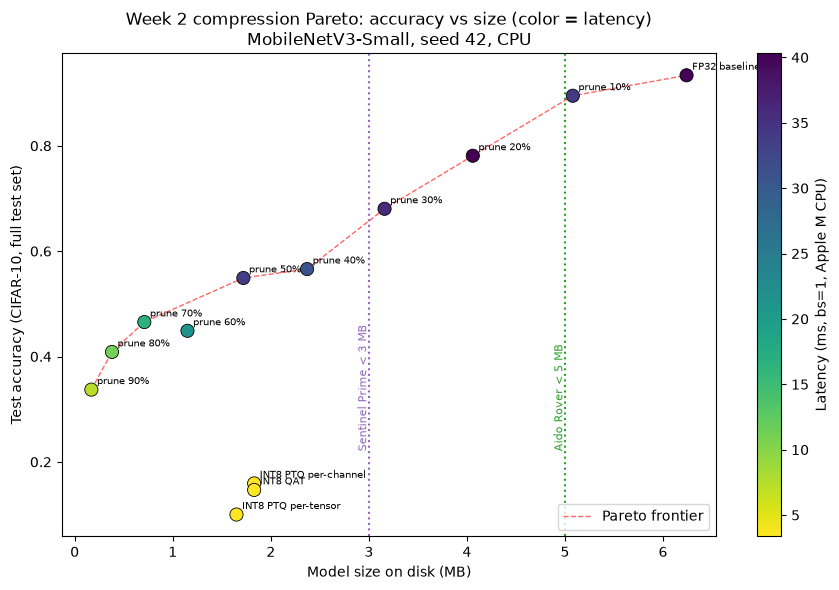

In [15]:
# Combined Pareto plot: every Week 2 configuration on one accuracy-vs-size
# chart, colored by latency (project plan W2: Pareto frontier analysis).
# Quantized configs are plotted even though accuracy collapsed - the plot
# itself tells the story: real size/latency gains, unusable accuracy.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Gather all configurations ---
prune = pd.read_csv('experiments/W02_pruning_sweep_ft3.csv')

rows = []
for _, r in prune.iterrows():
    label = 'FP32 baseline' if r['ratio'] == 0 else f"prune {int(r['ratio']*100)}%"
    rows.append((label, r['size_MB'], r['test_acc'], r['latency_ms']))

# Quantization line
rows.append(('INT8 PTQ per-channel', 1.83, 0.1591, 3.42))
rows.append(('INT8 PTQ per-tensor',  1.65, 0.1000, 3.36))
rows.append(('INT8 QAT',             1.83, 0.1467, 3.42))   # same scheme/artifact as per-channel; size & latency reused

df = pd.DataFrame(rows, columns=['config', 'size_MB', 'acc', 'latency_ms'])

# --- Pareto frontier: not dominated in BOTH size and accuracy ---
def is_pareto(df):
    flags = []
    for i, a in df.iterrows():
        dominated = ((df['size_MB'] <= a['size_MB']) & (df['acc'] >= a['acc']) &
                     ((df['size_MB'] < a['size_MB']) | (df['acc'] > a['acc']))).any()
        flags.append(not dominated)
    return flags

df['pareto'] = is_pareto(df)
print(df[df['pareto']][['config', 'size_MB', 'acc', 'latency_ms']])

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(df['size_MB'], df['acc'], c=df['latency_ms'], cmap='viridis_r',
                s=90, edgecolors='black', linewidths=0.6, zorder=3)
fig.colorbar(sc, label='Latency (ms, bs=1, Apple M CPU)')

pf = df[df['pareto']].sort_values('size_MB')
ax.plot(pf['size_MB'], pf['acc'], 'r--', lw=1, alpha=0.6, zorder=2,
        label='Pareto frontier')

ax.axvline(5, color='tab:green', ls=':', lw=1.5)
ax.axvline(3, color='tab:purple', ls=':', lw=1.5)
ax.annotate('Aido Rover < 5 MB', xy=(5, 0.22), color='tab:green',
            fontsize=8, rotation=90, va='bottom', ha='right')
ax.annotate('Sentinel Prime < 3 MB', xy=(3, 0.22), color='tab:purple',
            fontsize=8, rotation=90, va='bottom', ha='right')

for _, r in df.iterrows():
    ax.annotate(r['config'], xy=(r['size_MB'], r['acc']),
                xytext=(4, 4), textcoords='offset points', fontsize=7)

ax.set_xlabel('Model size on disk (MB)')
ax.set_ylabel('Test accuracy (CIFAR-10, full test set)')
ax.set_title('Week 2 compression Pareto: accuracy vs size (color = latency)\n'
             'MobileNetV3-Small, seed 42, CPU')
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig('experiments/W02_pareto_combined.png', dpi=150)
plt.show()

## Observations

**1. PTQ collapses in every configuration.** Per-channel Histogram 15.91%,
per-tensor MinMax 10.0% (full test set), per-channel MinMax 12.2% and the
official default mapping 10.2% (1k quick-screen), against a 93.38% FP32
baseline. Direction matches Nagel et al. (per-tensor worse than
per-channel); magnitude far exceeds the typical few-point PTQ loss.

**2. The size and latency gains are real.** 6.24 MB → 1.83 MB (3.4×
smaller) and 38.5 ms → 3.42 ms (~11× faster, bs=1, 10 warmup + 100 timed
runs). INT8 fails here on accuracy only — which is exactly why accuracy
and latency must always be reported together.

**3. The collapse is fully diagnosed.** Single-layer INT8 error is normal
→ kernels correct; observer and config swaps don't help → not a
calibration/configuration issue; QAT fake-quant ≈ true INT8 → failure
exists in simulation, backend-independent; **Experiment A: weight-only
quantization keeps 90.64%** (full test set) → weights innocent;
**Experiment B: stem output range ≈1986 vs network median 14.95 (133×)**
→ the INT8 grid at that tensor destroys all normal-magnitude activations
and the damage propagates.

**4. Selective FP32 fallback cannot rescue it (14.7%, verified).** The
outlier tensor must still cross an INT8 boundary; the FP32 region would
have to extend through most of the early network, forfeiting the
compression benefit. QAT (lr 1e-4, 3 ep, `scripts/qat_train.py`) converges
in training loss (1.90 → 0.58) but cannot fix an activation-distribution
pathology of this magnitude within a small budget.

**5. Conclusion.** This model's activation distribution is fundamentally
incompatible with uniform INT8 quantization: PTQ and short-budget QAT both
fail. INT4 was not attempted (no CPU INT4 inference path in this toolchain
on macOS; mechanistically a 2× coarser grid can only worsen the same
pathology). For the Sentinel < 3 MB budget, the viable route is
quantization-friendly training or a smaller architecture via knowledge
distillation (Week 3).

**Hardware qualifier**: latency figures are Apple M / qnnpack numbers;
ratios (3.4× size, ~11× speed) are expected to transfer to ARM Cortex-A
class hardware; absolute values are not.